# Landmark selection in 2D: random sampling, FPS, and well-tempered FPS

This notebook compares a few simple strategies to select **landmarks** from a cloud of points.

The goal is to build some geometric intuition:

- **Random sampling** follows the data density.
- **Farthest Point Sampling (FPS)** spreads landmarks across space.
- **Well-tempered FPS** interpolates between density-driven and diversity-driven selection.

The example is intentionally simple: a synthetic 2D dataset made of three Gaussian clusters.


## Imports and reproducibility

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)


## A small geometric helper

We start with the Euclidean distance between two points.


In [2]:
def distance(a, b):
    """Return the Euclidean distance between two vectors a and b."""
    return np.linalg.norm(a - b)


## Weighted random selection with NumPy

This is the compact implementation: choose `N` rows from `R` using probabilities proportional to the weights `W`.

This version is concise and efficient, and it is usually the one you would use in practice.


In [3]:
def randsamp(N, R, W):
    """Sample N points from R with probabilities proportional to W."""
    R = np.asarray(R)
    W = np.asarray(W, dtype=float)
    probabilities = W / W.sum()
    indices = np.random.choice(len(R), size=N, replace=False, p=probabilities)
    return R[indices]


## The same idea, written more explicitly

The next function performs **weighted random sampling without replacement** in a more transparent way.
Every step of the algorithm is visible.

Compared with the original version, this implementation keeps track of **available indices** rather than testing whether a NumPy row is already in a Python list. That makes the logic more robust.


In [4]:
def select_random(N, W, R):
    """Explicit weighted sampling without replacement.

    Parameters
    ----------
    N : int
        Number of points to select.
    W : array-like
        Non-negative weights associated with each point.
    R : array-like
        Candidate points.

    Returns
    -------
    numpy.ndarray
        Selected landmark points.
    """
    R = np.asarray(R)
    W = np.asarray(W, dtype=float)

    if N > len(R):
        raise ValueError("Cannot select more points than available candidates.")

    available = np.ones(len(R), dtype=bool)
    landmarks = []

    for _ in range(N):
        available_indices = np.where(available)[0]
        available_weights = W[available_indices]
        threshold = available_weights.sum() * np.random.uniform(0.0, 1.0)

        cumulative = 0.0
        for j, wj in zip(available_indices, available_weights):
            cumulative += wj
            if threshold < cumulative:
                landmarks.append(R[j])
                available[j] = False
                break

    return np.asarray(landmarks)


## A simple version of FPS

FPS stands for **Farthest Point Sampling**. The idea is:

1. choose a first landmark,
2. find, for every data point, the distance to its **closest** selected landmark,
3. select the point for which this minimum distance is largest.

This produces a set of points that is well spread out in space.

The implementation below is intentionally straightforward, but it is very slow for large datasets because it uses nested Python loops.


In [5]:
def farthest_point_sampling(N, W, R):
    """Pedagogical but slow implementation of farthest point sampling."""
    R = np.asarray(R)
    W = np.asarray(W, dtype=float)

    # Select the first landmark at random, using the input weights.
    first_landmark = select_random(1, W, R)[0]
    landmarks = [first_landmark]

    for _ in range(1, N):
        max_min_distance = 0.0
        candidate_landmark = None

        for rr in R:
            min_distance = float("inf")
            for ll in landmarks:
                d = distance(ll, rr)
                if d < min_distance:
                    min_distance = d

            if min_distance > max_min_distance:
                max_min_distance = min_distance
                candidate_landmark = rr

        landmarks.append(candidate_landmark)

    return np.asarray(landmarks)


## A more efficient FPS implementation

The next function implements the same idea more efficiently:

- it stores, for each point, the distance to the **closest** selected landmark,
- when a new landmark is chosen, it only updates that array,
- the next landmark is simply the point with the largest current distance.

This is the practical implementation used later in the notebook.


In [6]:
def FPS(X, n=0, idx=None):
    """Farthest Point Sampling on a set of points.

    Parameters
    ----------
    X : numpy.ndarray, shape (N, d)
        Input points.
    n : int, optional
        Number of landmarks to select. If n <= 0, select all points.
    idx : int or None, optional
        Index of the first selected point. If None, choose it at random.

    Returns
    -------
    numpy.ndarray
        Selected landmark points.
    """
    X = np.asarray(X)
    N = X.shape[0]

    if n <= 0:
        n = N
    if n > N:
        raise ValueError("Cannot select more landmarks than the number of input points.")

    fps_indices = np.zeros(n, dtype=np.int32)

    if idx is None:
        idx = np.random.randint(0, N)
    fps_indices[0] = idx

    # Squared distances to the first selected point.
    min_dist_sq = np.linalg.norm(X - X[idx], axis=1) ** 2

    for i in range(1, n):
        fps_indices[i] = np.argmax(min_dist_sq)
        new_dist_sq = np.linalg.norm(X - X[fps_indices[i]], axis=1) ** 2
        min_dist_sq = np.minimum(min_dist_sq, new_dist_sq)

        if min_dist_sq.max() == 0.0:
            print(f"Only {i} unique FPS landmarks are possible.")
            return X[fps_indices[:i]]

    return X[fps_indices]


## Voronoi assignment and landmark weights

Once a set of landmarks is chosen, every data point can be assigned to its **closest landmark**.

This partitions the dataset into Voronoi-like regions. From this partition we can compute:

- the total weight associated with each landmark,
- the list of points belonging to each landmark region.

These quantities are used by the well-tempered FPS strategy.


In [7]:
def voronoi_weights(L, R, W):
    """Assign each point in R to the closest landmark in L.

    Returns
    -------
    weights : numpy.ndarray
        Total weight associated with each landmark.
    points : list of numpy.ndarray
        Points assigned to each landmark region.
    """
    L = np.asarray(L)
    R = np.asarray(R)
    W = np.asarray(W, dtype=float)

    weights = np.zeros(len(L))
    labels = np.zeros(len(R), dtype=int)

    for i, r in enumerate(R):
        distances = np.linalg.norm(L - r, axis=1)
        nearest = np.argmin(distances)
        weights[nearest] += W[i]
        labels[i] = nearest

    points = [R[labels == i] for i in range(len(L))]
    return weights, points


## Well-tempered FPS

This strategy mixes **coverage** and **density**:

1. first select many candidates with FPS,
2. build Voronoi regions around them,
3. assign a weight to each region,
4. reselect the final landmarks using a power-law bias controlled by `gamma`.

Interpretation of `gamma`:

- small `gamma` gives more emphasis to spatial coverage,
- larger `gamma` gives more emphasis to dense regions.

So `gamma` acts like a knob between “spread out” and “follow the data distribution”.


In [8]:
def wtfps_landmarks_selection(gamma, N, W, R):
    """Well-tempered FPS landmark selection.

    Parameters
    ----------
    gamma : float
        Exponent controlling the bias toward dense Voronoi regions.
    N : int
        Number of final landmarks.
    W : array-like
        Input weights on the data points.
    R : array-like
        Input points.

    Returns
    -------
    numpy.ndarray
        Final set of landmarks.
    """
    R = np.asarray(R)
    W = np.asarray(W, dtype=float)

    # Number of intermediate FPS landmarks.
    K = int(np.sqrt(len(R) * N))

    # Step 1: geometric preselection
    fps_landmarks = FPS(R, n=K, idx=None)

    # Step 2: compute Voronoi regions and their weights
    fps_weights, fps_points = voronoi_weights(fps_landmarks, R, W)

    # Step 3: sample Voronoi regions with tempered weights
    region_indices = np.arange(K)
    selected_regions = randsamp(N, region_indices, fps_weights ** gamma)

    # Step 4: pick one representative point from each selected region
    landmarks = [
        randsamp(1, fps_points[i], np.ones(len(fps_points[i])))[0]
        for i in selected_regions
    ]

    return np.asarray(landmarks)


## Build a toy dataset

We create three Gaussian clouds in 2D. All points are given equal weight here, so the only “density” information comes from how many points are present in each region of space.


In [9]:
N1 = 5000
N2 = 5000
N3 = 5000
Ns = 150  # number of landmarks to select

data1 = np.random.normal([4.0, 2.0], [1.0, 0.7], size=(N1, 2))
data2 = np.random.normal([8.1, 13.0], [2.0, 1.5], size=(N2, 2))
data3 = np.random.normal([14.0, 7.0], [1.5, 0.5], size=(N3, 2))

data = np.concatenate((data1, data2, data3), axis=0)
weights = np.ones(N1 + N2 + N3) / (N1 + N2 + N3)

print(f"Dataset size: {len(data)} points")
print(f"Selecting {Ns} landmarks")


Dataset size: 15000 points
Selecting 150 landmarks


## Select landmarks with the different strategies


In [10]:
lm = randsamp(Ns, data, weights)
lm_fp = FPS(data, n=Ns, idx=None)
lm_gfp1 = wtfps_landmarks_selection(0.25, Ns, weights, data)
lm_gfp2 = wtfps_landmarks_selection(1.0, Ns, weights, data)
lm_gfp3 = wtfps_landmarks_selection(4.0, Ns, weights, data)


## Prepare the arrays for plotting


In [11]:
x_data, y_data = data.T
x_rand, y_rand = lm.T
x_fps, y_fps = lm_fp.T
x_g1, y_g1 = lm_gfp1.T
x_g2, y_g2 = lm_gfp2.T
x_g4, y_g4 = lm_gfp3.T


## Visual comparison

When reading the figure, focus on the tradeoff between two goals:

- **represent the full space** well,
- **respect the local density** of the data.

Random sampling tends to place many landmarks where many points already exist.
FPS spreads them more uniformly.
Well-tempered FPS can interpolate between those two behaviors.


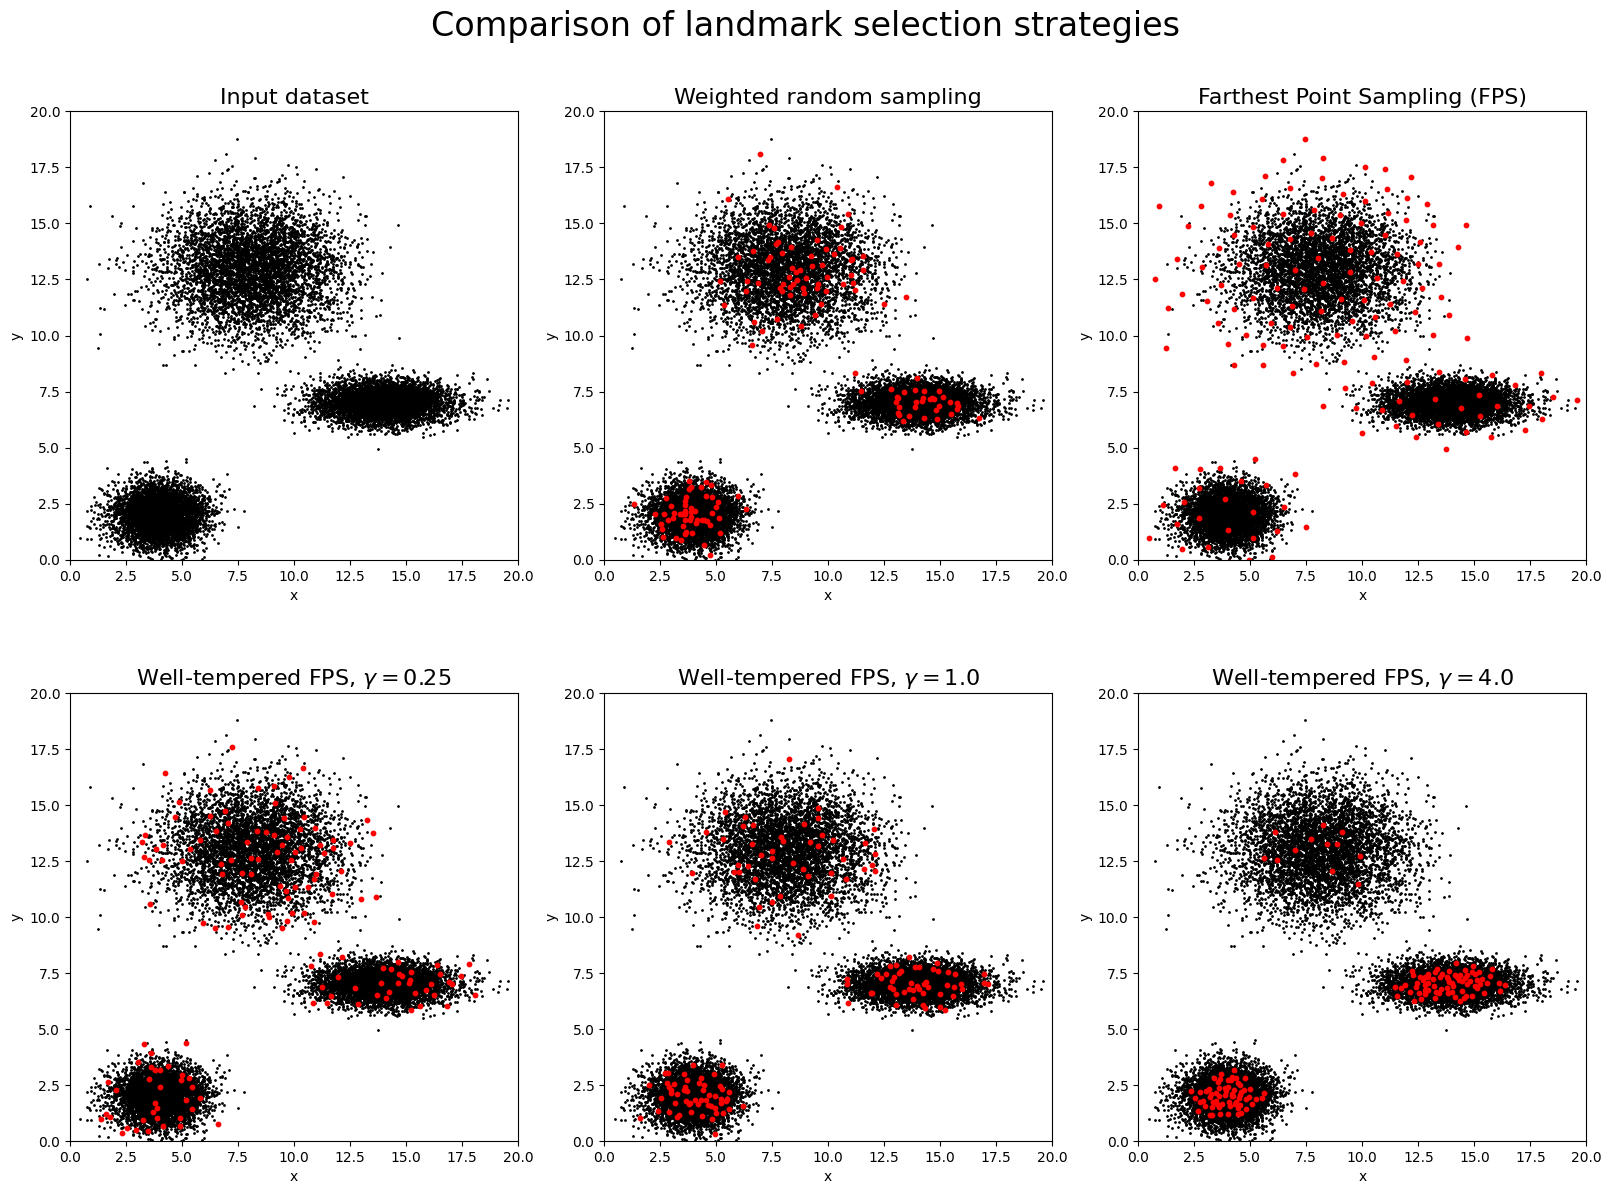

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 12), constrained_layout=True)
fig.suptitle("Comparison of landmark selection strategies", fontsize=24)

for ax in axs.ravel():
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axs[0, 0].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[0, 0].set_title("Input dataset", fontsize=16)

axs[0, 1].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[0, 1].scatter(x_rand, y_rand, s=10, c="red", marker="o")
axs[0, 1].set_title("Weighted random sampling", fontsize=16)

axs[0, 2].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[0, 2].scatter(x_fps, y_fps, s=10, c="red", marker="o")
axs[0, 2].set_title("Farthest Point Sampling (FPS)", fontsize=16)

axs[1, 0].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[1, 0].scatter(x_g1, y_g1, s=10, c="red", marker="o")
axs[1, 0].set_title(r"Well-tempered FPS, $\gamma = 0.25$", fontsize=16)

axs[1, 1].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[1, 1].scatter(x_g2, y_g2, s=10, c="red", marker="o")
axs[1, 1].set_title(r"Well-tempered FPS, $\gamma = 1.0$", fontsize=16)

axs[1, 2].scatter(x_data, y_data, s=1, c="black", marker="o")
axs[1, 2].scatter(x_g4, y_g4, s=10, c="red", marker="o")
axs[1, 2].set_title(r"Well-tempered FPS, $\gamma = 4.0$", fontsize=16)

plt.show()


## Take home message

A useful way to interpret the panels is:

- **Random sampling** mirrors the population of the clusters.
- **FPS** gives broad geometric coverage, even in sparse regions.
- **Well-tempered FPS** lets us tune the compromise:
  - smaller `gamma` stays closer to the spirit of FPS,
  - larger `gamma` increasingly favors high-density regions.

This is why these strategies are useful in atomistic machine learning:
we often want a compact set of representative structures, but “representative” can mean either *geometrically diverse* or *weighted toward what occurs most often*.
